In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import random 
import pickle

In [2]:
# Importing split datasets 
with open ("/kaggle/input/datase/train_dev_test_data.pkl", "rb") as f:
    X_train, X_dev, X_test, y_train, y_dev, y_test = pickle.load(f)

In [3]:
# Convert dataframes to a matrices for Logistic regression implementation
def to_numpy_format(df): 
    data = df.to_numpy()
    data = data.T 
    return data

X_train, X_dev, X_test, y_train, y_dev, y_test = [to_numpy_format(df) for df in [X_train, X_dev, X_test, y_train, y_dev, y_test]]

In [4]:
# Initializing parameters
def initialize_parameters (X, n_h, Y): 
    np.random.seed(1)
    n_x = X.shape[0]
    n_y = Y.shape[0]
    W1 = np.random.randn(n_h, n_x)
    b1 = np.zeros((n_h,1))
    W2 = np.random.randn(n_y,n_h)
    b2 = np.zeros((n_y,1))
    
    parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return parameters
def sigmoid (z):
    AL = 1/ (1+np.exp(-z))
    return AL 
def Relu (z) : 
    A = np.maximum(0,z)
    return A 
def forward (X,W,b): 
    Z = np.dot(W,X) + b 
    return Z
def compute_cost(A, Y): 
    m = Y.shape[1]
    cost = (-1/m) * np.sum((Y*np.log(A)) + ((1-Y) * np.log(1-A)))
    return cost 
def activation (X,W,b, activation) : 
    Z = forward (X, W, b)
    if activation == 'relu' : 
        A = Relu (Z)
    else:
        A = sigmoid (Z)
    return Z, A 
def relu_derivative(Z):
    """
    Computes the derivative of ReLU element-wise.
    Returns 1 where Z > 0, 0 otherwise.
    """
    dZ = np.array(Z, copy=True)       # make a copy of Z
    dZ[Z <= 0] = 0                    # set derivative to 0 where Z <= 0
    dZ[Z > 0] = 1                     # optional, already 1 but explicit
    return dZ
    
def compute_gradient (X, Y, Z1, A1, AL, W2):
    m = X.shape[1]
    # Computing output layers gradients
    dZ2 = AL - Y # (1,m)
    dW2 = (1/m) * (np.dot(dZ2, A1.T))  # (1, n_h)           
    db2 = (1/m) * (np.sum(dZ2, axis =1, keepdims = True)) # (1,1)
    # Computing hidden layer gradients 
    dA1 = np.dot(W2.T, dZ2) # (n_h, m)
    dZ1 = dA1 * relu_derivative(Z1) # (n_h, m)
    dW1 = (1/m) * np.dot(dZ1, X.T) # (n_h,n_x)
    db1 = (1/m) * (np.sum(dZ1, axis =1, keepdims =True)) # (n_h, 1)
    gradients = {"dW1": dW1, "db1": db1,
                 "dW2": dW2, "db2": db2}
    return gradients 
    
def update_gradients (parameters, gradients, learning_rate):
    parameters["W1"] = parameters["W1"] - learning_rate * gradients["dW1"]
    parameters["b1"] = parameters["b1"] - learning_rate * gradients["db1"]
    parameters ["W2"] = parameters["W2"] - learning_rate * gradients["dW2"]
    parameters ["b2"] = parameters["b2"] - learning_rate * gradients["db2"]
    
    return parameters 

    

def model (X, Y, n_h, num_iterations, learning_rate, print_cost) : 
    costs = []
    parameters = initialize_parameters(X, n_h, Y)
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters ["b2"]
    for i in range (num_iterations): 
        Z1, A1 = activation (X, W1, b1, activation ='relu')
        Z2, AL = activation (A1, W2, b2, activation='sigmoid')
        cost = compute_cost(AL,Y)
        costs.append(cost)
        gradients = compute_gradient(X,Y,Z1,A1,AL,W2)
        parameters = update_gradients(parameters,gradients,learning_rate)
        W1 = parameters["W1"]
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]
        if print_cost and i % 100 == 0 : 
            print (f"cost at iteration {i} = {cost}") 
    return parameters, costs

In [5]:
parameters, costs = model(X_train, y_train, 10, num_iterations = 2000, learning_rate = 0.3, print_cost = False)

In [6]:
def predict (X,parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    _, A1 = activation (X, W1, b1, activation= 'relu')
    _, y_pred = activation (A1, W2, b2, activation= 'sigmoid')
    y_pred = (y_pred > 0.5).astype(int)
    return y_pred
def accuracy(y_true, y_pred):
    acc = 100 * np.mean(y_true == y_pred)
    return acc


In [8]:
y_train_pred = predict(X_train, parameters)
train_acc = accuracy(y_train, y_train_pred)
y_dev_pred = predict(X_dev, parameters)
dev_acc = accuracy(y_dev, y_dev_pred)
y_test_pred = predict(X_test, parameters)
test_acc = accuracy(y_test, y_test_pred)
print (f"Training Accuracy {train_acc}")
print(f"Development Accuracy {dev_acc}")
print (f"Testing Accuracy {test_acc}")

Training Accuracy 96.05300993936363
Development Accuracy 95.90918183636728
Testing Accuracy 95.94959495949595


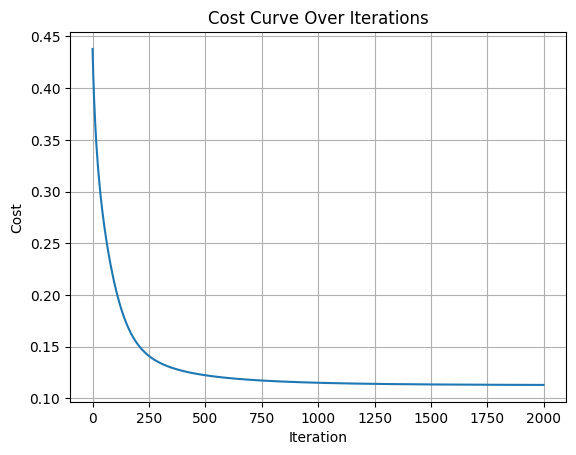

In [9]:
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Curve Over Iterations")
plt.grid(True)
plt.show()